In [ ]:
import marimo as mo

# import numpy as np
from sklearn.neighbors import (
    KNeighborsClassifier,
)  # non serve importare tutto sklearn
from sklearn.model_selection import train_test_split

# import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

Matplotlib is building the font cache; this may take a moment.


# Algoritmo k-NN e prima applicazione di sklearn

Il **k-NN** (*k-nearest neighbors*) è un semplice algoritmo *supervisionato*. L'idea di fondo è, in maniera concettualmente simile (**ma non coincidente**) al k-means clustering, di considerare $k$ punti "vicini" ad un certo dato ed assegnare al dato selezionato la classe più popolare in quel gruppo.
***

## Passaggi preliminari

Come prima cosa vanno importati i dati su cui operare: successivamente li facciamo partizionare (con una funzione dedicata di `sklearn`) in un *test dataset* (quello che "contiene le risposte giuste") e un *training dataset* (quello che l'algoritmo usa per "imparare").

Il dataset di esempio qui (e spesso trovato come esempio) è quello di un insieme di 150 immagini del fiore iris, ***bilanciato*** nelle 3 classi *versicolor, virginica e setosa*. Le feature utilizzate sono:
- lunghezza e larghezza del petalo
- lunghezza e larghezza del sepalo
> L'implicazione del bilanciamento delle classi è che nelle metriche di interesse sulla performance dell'algoritmo non abbiamo bisogno di usare la loro versione "percentuale".

Il dataframe risultante è dunque un array

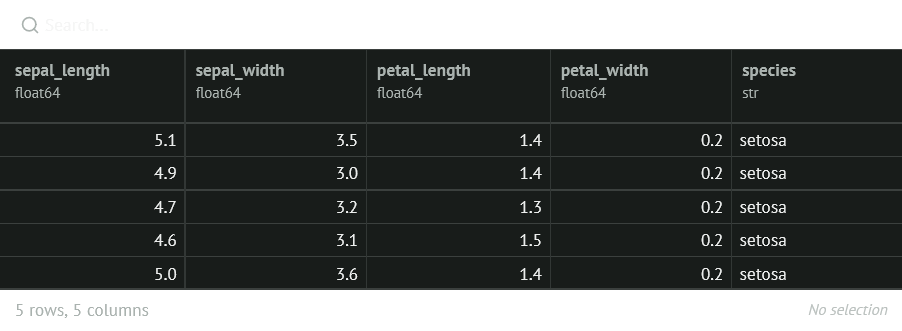

In [ ]:
df = sns.load_dataset("iris")

df.head()

Osserviamo il *pair plot* delle 4 feature. Le tipologie di iris sono classificate da `species`, per cui si specifica che la separazione dei colori è rispetto a quel parametro:

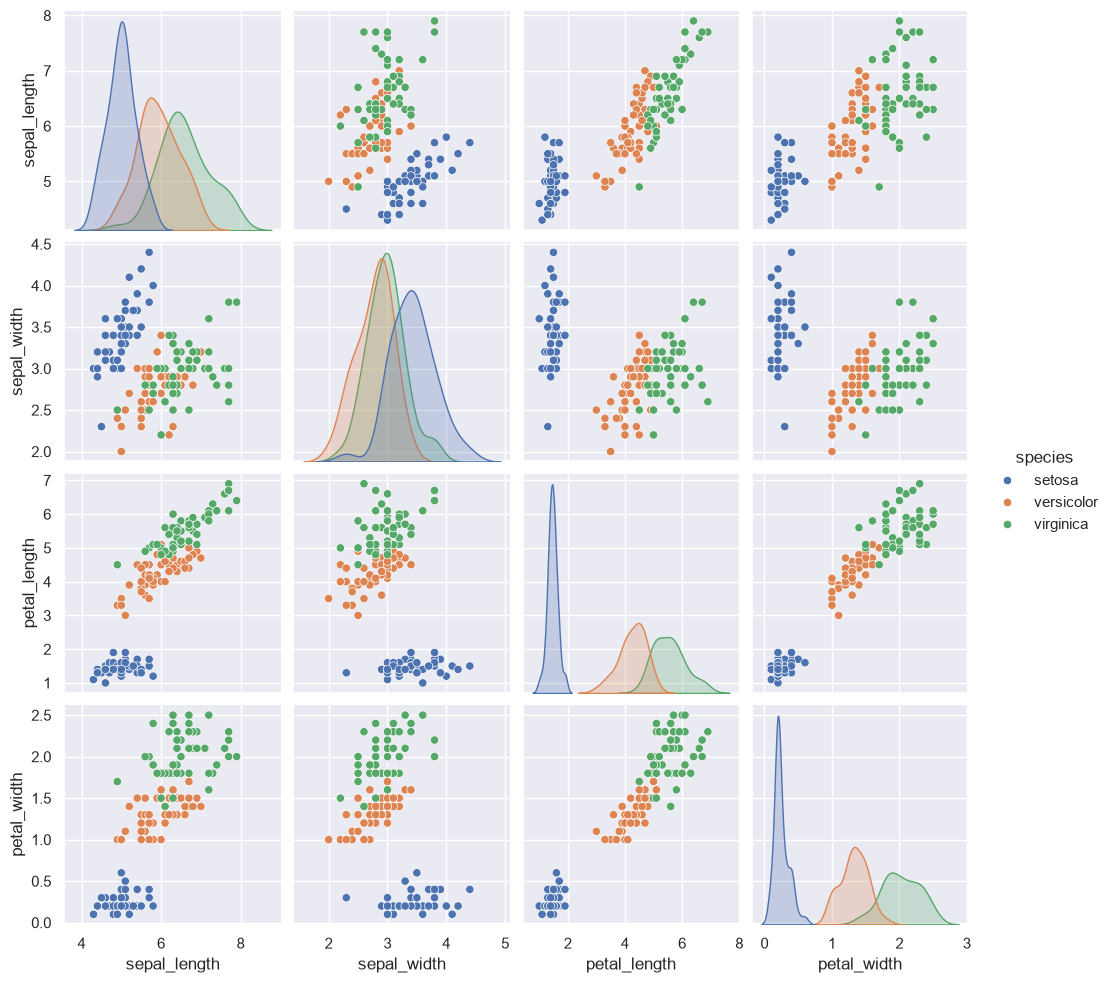

In [ ]:
sns.pairplot(data=df, hue="species")

**Gli elementi in diagonale mostrano solo le distribuzioni rispetto a quella feature**.

Immediatamente si nota che molte delle feature sono discriminanti, con l'eccezione della copia `sepal_length, sepal_width` dove vi è una sovrapposizione più notevole.

Per questioni sia di funzionamento del metodo che di memoria siamo soliti appiattire il dataset: invece di avere $n$ vettori con $k$ feature (per una matrice di dimensione $n \times k$) passiamo una lista di liste (che all'atto pratico è un array unidimensionale di $n$ elementi lunghi $k$).

In [ ]:
x = df.iloc[
    :, 0:4
]  # questo prende il set di dati considerando solo le feature

y = df["species"].values.ravel()
# questo prende il set di dati sulla sola caratteristica sulla quale vogliamo che il modello faccia la previsione, in questo caso a partire dalle dimensioni di petali e sepali deve predire la specie

# print(dataset)

Separo il dataset: `train_test_split` è definita tale da prendere gli array forniti (quanti essi siano, qui 2) e suddividere ciascuno di essi in insieme di training e insieme test, per cui a destra, avendogli passato x ed y, restituisce la suddivisione di x e la suddivisione di y.
- `random_state` è semplicemente il seed che la funzione utilizza quando raggruppa i dati nei set di training e test. Qui è assegnato un valore fisso, ma nulla toglie (ed è anzi forse meglio) passare un `rand` per controllare che il modello sia performante in generale.
- `stratify` è necessario per mantenere le propozioni: vogliamo che le 3 specie di iris continuino ad essere equipartite in ciascun set, dunque passiamo `y`.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

Vanno ora standardizzate le feature: utilizzo lo *standard scaler*, sapendo a priori che abbiamo un set di valori distribuiti normalmente. Di cruciale importanza è che il fitting (ergo il calcolo di media e deviazione standard) e la trasformazione (i dati vengano traslati e scalati alla gaussiana con i sopracitati parametri) avvengano **SOLO** sui dati di training. Il set di test è invece solo trasformato, ma il fitting è effettuato in base a media/stdev calcolati sul set di training.

Il motivo è prevenire un fenomeno di "leakage" dei dati: il modello non deve venire a contatto con i parametri della distribuzione (quali media e varianza), altrimenti l'algoritmo sarà soggetto ad overfitting relativamente a quei parametri e diventa incapace di riconoscere correttamente un nuovo set di dati la cui distribuzione ha parametri differenti.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = (
    StandardScaler()
)  # è convenzione passarlo ad una variabile per qualche motivo

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Implementazione del modello

A questo punto si chiama il metodo apposito. Impostiamo $k=5$ e la metrica euclidea.

In [ ]:
model = KNeighborsClassifier(metric="euclidean")